# Phase 3 (part 14): CICIDS2017 cross-dataset replication of the neural benchmark (MLP), with the explainer control inline

**What this is.** The cross-dataset check on the one surprising result. On UNSW
(notebook 13), the pre-vs-post domain-SHAP localizer beat a label-free KS test for
the **MLP** but not the trees, and the control (13b) showed it was the model, not
the explainer. The obvious reviewer question is: *does that neural boundary hold
on a second dataset, or is it a UNSW quirk?* CICIDS2017 is the fair stress test --
more features, higher redundancy (median $\approx 0.95$ vs $0.90$), different
geometry.

**Design.** The notebook-13 construction, held identical, with CICIDS swapped in:
- **Drift:** additive leave-one-family-out -- post = baseline + family H injected
  at prevalence `INJECT_P`, baseline held constant. Families come from
  `meta['attack_category']`.
- **Drift-localizers:** KS, domain-SHAP, dual-IDS, perm-domain, random.
- **Anchor:** per-feature Wasserstein-1 (model-free drift truth).
- RF + XGBoost + MLP; several held-out families; self-stability.
- SHAP via `shap_importance_any` (TreeSHAP for RF/XGB, the validated agnostic path
  for the MLP, F016).

**Inline explainer control (13b analog, on CICIDS).** For the tree domain
classifiers we *also* compute domain-SHAP via the same `PermutationExplainer` the
MLP uses, so the same notebook answers both questions on CICIDS: does the MLP
advantage replicate, and -- if so -- is it the model or the explainer.

**Pre-registered gate (D032), headline = the MLP, on the Wasserstein anchor
(margin 0.05).** Two parts:
- *Replication* (native explainers): `C2-REPLICATES-NEURAL-CICIDS` iff
  `dual_mlp - domain_shap_mlp <= m` and `KS - domain_shap_mlp >= -m`;
  `EXPLANATION-ADDS-VALUE-NEURAL-CICIDS` iff `dual_mlp - domain_shap_mlp <= m`
  and `domain_shap_mlp - KS > m`; `DUAL-HELPS-NEURAL-CICIDS` iff
  `dual_mlp - domain_shap_mlp > m`.
- *Control* (same `PermutationExplainer` on the trees): `MODEL-DRIVEN-CICIDS` iff
  the trees stay competitive with KS under PermutationExplainer
  ($\text{KS}-\text{domSHAP}_{perm}\ge-m$) while the MLP beats it;
  `EXPLAINER-DRIVEN-CICIDS` iff the trees flip to beating KS under it too.

Reading the two together tells the paper whether the UNSW neural boundary is
**cross-dataset robust** (replicates + model-driven on CICIDS) or **UNSW-specific**
(does not replicate) -- either is reportable.

**Runtime.** ~45--70 min on a Colab hi-RAM instance (CICIDS is large and the
PermutationExplainer calls dominate, now also on the trees). **Run a smoke check
first**: set `SEEDS=[42]` and `N_HELDOUT=1`.

This is the **last** experiment. After it: paper polish, no more models.

Numbering: 14, a Phase-3 generalization notebook (`05_phase3_generalization/`).
Requires the F016 functions in `src/divergence/localization.py` (notebook 11, step 1).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, glob
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, wasserstein_distance

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    jaccard, random_precision_expectation,
)
try:
    from src.divergence.localization import shap_importance_any, agnostic_shap_importance
except ImportError as e:
    raise ImportError(
        'Add agnostic_shap_importance and shap_importance_any to '
        'src/divergence/localization.py first (notebook 11, step 1).'
    ) from e

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase3_14_mlp_cicids_benchmark.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
RF_PARAMS = meta06['rf_hyperparameters']
META_FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06.get('constant_features_dropped', [])

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
MODEL_COLOR = {'rf': '#E69F00', 'xgb': '#009E73', 'mlp': '#56B4E9'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='14_mlp_cicids_benchmark'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

Setup complete.


## 2. D032 — CICIDS cross-dataset replication (with inline explainer control)

In [3]:
log_decision(
    decision_id='D032',
    decision=(
        'Replicate the UNSW neural drift-localization benchmark (13 / D030) on '
        'CICIDS2017, construction held identical (additive leave-one-family-out, '
        'per-feature Wasserstein anchor, KS / domain-SHAP / dual-IDS / perm-domain / '
        'random, RF + XGBoost + MLP, families from attack_category, self-stability), '
        'and fold the 13b explainer control inline: for the tree domain classifiers '
        'also compute domain-SHAP via the same PermutationExplainer the MLP uses. SHAP '
        'via shap_importance_any. Pre-registered gate (margin 0.05, headline=MLP, '
        'Wasserstein anchor): replication tier C2-REPLICATES-NEURAL-CICIDS iff '
        'dual_mlp-domSHAP_mlp <= m AND KS-domSHAP_mlp >= -m (else EXPLANATION-ADDS-'
        'VALUE / DUAL-HELPS); control tier MODEL-DRIVEN-CICIDS iff trees stay >= -m vs '
        'KS under PermutationExplainer while the MLP beats it, else EXPLAINER-DRIVEN-'
        'CICIDS. CICIDS pool stratified-capped at POOL_CAP rows by attack_category for '
        'memory/runtime.'
    ),
    rationale=(
        'The notebook-13 neural boundary (domain-SHAP beats KS for the MLP) rests on one '
        'dataset; a reviewer will ask whether it is dataset-specific. CICIDS is the fair '
        'stress test (more features, higher redundancy, different geometry). Holding the '
        'construction fixed and only changing the dataset gives a clean cross-dataset '
        'test; including the explainer control on CICIDS pre-empts the same confound 13b '
        'closed on UNSW. This is cross-dataset replication of the existing model, not a '
        'new model class -- consistent with the disciplined scope.'
    ),
    alternatives=(
        'Mirror the CICIDS 07-series cold-start day-stream instead (rejected: not '
        'construction-comparable to 13; would confound dataset with drift design). Skip '
        'CICIDS and state UNSW-only as a limitation (a legitimate alternative; chosen '
        'against here to make the neural boundary cross-dataset). Add more model classes '
        '(rejected: out of scope).'
    ),
)

[DECISION LOGGED] D032


## 3. Configuration (identical to 13; plus a CICIDS pool cap)

In [4]:
set_global_seed(42)

WINDOW = 4000
INJECT_P = 0.5
ANCHOR_N = 4000
ORACLE_N = 4000
SHAP_SAMPLE = 800
SEEDS = [42, 1, 7]
MODELS = ['rf', 'xgb', 'mlp']
N_HELDOUT = 3
MIN_FAMILY = 3000
K_PRIMARY = 10
GTS = ['wasserstein', 'domain_oracle_shap']
MARGIN = 0.05
POOL_CAP = 400000          # stratified-by-family cap on CICIDS rows (memory/runtime)

MLP_PARAMS = dict(hidden_layer_sizes=(256, 128, 64), activation='relu',
                  alpha=1e-4, max_iter=300, early_stopping=True,
                  n_iter_no_change=15, random_state=42)   # == notebooks 11/12/13

print(f'CICIDS replication of notebook 13. Models {MODELS}, seeds {SEEDS}, pool cap {POOL_CAP:,}.')
print(f'Gate (margin {MARGIN}, headline=MLP): replication + inline explainer control.')

CICIDS replication of notebook 13. Models ['rf', 'xgb', 'mlp'], seeds [42, 1, 7], pool cap 400,000.
Gate (margin 0.05, headline=MLP): replication + inline explainer control.


## 4. Load CICIDS2017 (canonical features) and cap the pool

Uses the project loader and the `phase1_06_metadata.json` feature contract (drops
the constant features). The full CICIDS is large, so we stratified-subsample by
attack family to `POOL_CAP` rows -- this preserves family diversity while bounding
memory and runtime. Set `POOL_CAP` higher if you have the RAM.

In [5]:
X_df, y_ser, meta_df = load_cicids2017()
print('loaded CICIDS:', X_df.shape)

X_df = X_df.drop(columns=CONSTANT_FEATURES, errors='ignore')
FEATURE_COLS = [c for c in META_FEATURE_COLS if c in X_df.columns]
N_FEATURES = len(FEATURE_COLS)

Xall = X_df[FEATURE_COLS].to_numpy(dtype=np.float32)
y = y_ser.to_numpy().astype(int)
fam = meta_df['attack_category'].astype(str).str.strip().to_numpy()
finite = np.isfinite(Xall).all(axis=1)
Xall, y, fam = Xall[finite], y[finite], fam[finite]

# stratified-by-family cap
if len(y) > POOL_CAP:
    rng0 = np.random.default_rng(42)
    frac = POOL_CAP / len(y)
    keep = []
    for g in pd.unique(fam):
        gidx = np.where(fam == g)[0]
        n_keep = min(len(gidx), max(1, int(round(len(gidx) * frac))))
        keep.append(rng0.choice(gidx, size=n_keep, replace=False))
    keep = np.concatenate(keep)
    Xall, y, fam = Xall[keep], y[keep], fam[keep]
    print(f'capped to {len(y):,} rows (stratified by attack_category)')

mu, sd = Xall.mean(0), Xall.std(0); sd[sd == 0] = 1.0
Xz = ((Xall - mu) / sd).astype(np.float32)
CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)
benign_mask = (y == 0)

print(f'features {N_FEATURES} | rows {len(y):,} | benign {int(benign_mask.sum()):,} | '
      f'attack {int((~benign_mask).sum()):,} | chance precision@{K_PRIMARY} = {CHANCE:.3f}')
fam_counts = pd.Series(fam[~benign_mask]).value_counts()
print('\nattack family counts:'); print(fam_counts.to_string())

loaded CICIDS: (2099971, 82)
capped to 399,999 rows (stratified by attack_category)
features 82 | rows 399,999 | benign 301,444 | attack 98,555 | chance precision@10 = 0.122

attack family counts:
Portscan                      30299
DoS Hulk                      30295
DDoS                          18123
Infiltration - Portscan       13670
DoS GoldenEye                  1457
DoS Slowloris                  1087
DoS Slowhttptest                973
Botnet                          915
FTP-Patator                     759
SSH-Patator                     569
Web Attack - Brute Force        260
Web Attack - XSS                128
Infiltration                     15
Web Attack - SQL Injection        3
Heartbleed                        2


## 5. Select held-out families

In [6]:
fam_counts = pd.Series(fam[~benign_mask]).value_counts()
eligible = [f for f in fam_counts.index
            if fam_counts[f] >= MIN_FAMILY and f.lower() not in ('normal', 'benign')]
HELDOUT = eligible[:N_HELDOUT]
assert len(HELDOUT) >= 1, f'no attack family has >= {MIN_FAMILY} rows after capping'
print(f'Held-out families (drift scenarios): {HELDOUT}')
for h in HELDOUT:
    print(f'  {h}: {int(fam_counts[h])} rows')

Held-out families (drift scenarios): ['Portscan', 'DoS Hulk', 'DDoS']
  Portscan: 30299 rows
  DoS Hulk: 30295 rows
  DDoS: 18123 rows


## 6. Run the benchmark + inline explainer control

Per (family, model, seed): the notebook-13 benchmark (KS, domain-SHAP via the
native explainer, dual-IDS, perm-domain, random; Wasserstein + domain-oracle-SHAP
GTs; self-stability). For the tree domain classifiers, also compute domain-SHAP via
PermutationExplainer (the control) and record it separately.

In [7]:
def make_model(kind, seed):
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    if kind == 'mlp':
        return MLPClassifier(**{**MLP_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

def norm(v):
    v = np.abs(np.asarray(v, float)); s = v.sum(); return v / s if s > 0 else v

def take(pool, n, rng):
    idx = rng.choice(pool, size=min(n, len(pool)), replace=False)
    return Xz[idx], (~benign_mask[idx]).astype(int)

def additive_post(base_pool, hold_pool, n, rng):
    n_h = int(round(n * INJECT_P)); n_b = n - n_h
    bX, by = take(base_pool, n_b, rng); hX, hy = take(hold_pool, n_h, rng)
    X = np.vstack([bX, hX]); yids = np.concatenate([by, hy])
    order = rng.permutation(len(X)); return X[order], yids[order]

def imp(model, X_eval, X_bg, seed=42):
    return norm(shap_importance_any(model, X_eval, X_bg=X_bg, seed=seed))

rows, stab, ctrl_rows = [], [], []
t0 = time.time()
for H in HELDOUT:
    base_pool = np.where(benign_mask | (fam != H))[0]
    hold_pool = np.where((~benign_mask) & (fam == H))[0]

    arng = np.random.default_rng(777)
    preA, _ = take(base_pool, ANCHOR_N, arng)
    postA, _ = additive_post(base_pool, hold_pool, ANCHOR_N, arng)
    wass = np.array([wasserstein_distance(preA[:, j], postA[:, j]) for j in range(N_FEATURES)])

    for model in MODELS:
        oPre, _ = take(base_pool, ORACLE_N, arng)
        oPost, _ = additive_post(base_pool, hold_pool, ORACLE_N, arng)
        oX = np.vstack([oPre, oPost]); oy = np.r_[np.zeros(len(oPre), int), np.ones(len(oPost), int)]
        odom = make_model(model, 42).fit(oX, oy)
        oi = np.random.default_rng(42).choice(len(oX), size=min(SHAP_SAMPLE, len(oX)), replace=False)
        gt_scores = {'wasserstein': norm(wass), 'domain_oracle_shap': imp(odom, oX[oi], oX, seed=42)}
        gt_sets = {g: set(int(i) for i in topk_indices(s, K_PRIMARY)) for g, s in gt_scores.items()}
        gtW = gt_sets['wasserstein']

        per_seed_topk = {m: [] for m in ['ks', 'domain_shap', 'dual_ids', 'perm_domain', 'random']}
        for seed in SEEDS:
            rng = np.random.default_rng(seed)
            preX, pre_y = take(base_pool, WINDOW, rng)
            postX, post_y = additive_post(base_pool, hold_pool, WINDOW, rng)

            f_pre = make_model(model, seed).fit(preX, pre_y)
            f_post = make_model(model, seed).fit(postX, post_y)
            sh = postX[rng.choice(len(postX), size=min(SHAP_SAMPLE, len(postX)), replace=False)]
            dual_ids = np.abs(imp(f_post, sh, postX, seed=seed) - imp(f_pre, sh, preX, seed=seed))

            domX = np.vstack([preX, postX])
            domy = np.r_[np.zeros(len(preX), int), np.ones(len(postX), int)]
            dtr, dev = train_test_split(np.arange(len(domy)), train_size=0.7,
                                        stratify=domy, random_state=seed)
            dom = make_model(model, seed).fit(domX[dtr], domy[dtr])
            di = rng.choice(dev, size=min(SHAP_SAMPLE, len(dev)), replace=False)

            # native-explainer domain-SHAP (TreeSHAP for trees, Perm for MLP) -- the 13 benchmark
            if model in ('rf', 'xgb'):
                domain_shap = norm(shap_importance(dom, domX[di]))
                domain_shap_perm = norm(agnostic_shap_importance(dom, domX[di], X_bg=domX[dtr], seed=seed))
                ctrl_rows.append({'family': H, 'model': model, 'seed': seed, 'variant': 'treeshap',
                                  'precision': precision_at_k(domain_shap, gtW, K_PRIMARY),
                                  'agree_tree_perm': float('nan')})
                rho_tp = spearmanr(domain_shap, domain_shap_perm).correlation
                ctrl_rows.append({'family': H, 'model': model, 'seed': seed, 'variant': 'perm',
                                  'precision': precision_at_k(domain_shap_perm, gtW, K_PRIMARY),
                                  'agree_tree_perm': float(rho_tp) if rho_tp == rho_tp else 0.0})
            else:
                domain_shap = norm(agnostic_shap_importance(dom, domX[di], X_bg=domX[dtr], seed=seed))
                ctrl_rows.append({'family': H, 'model': model, 'seed': seed, 'variant': 'perm',
                                  'precision': precision_at_k(domain_shap, gtW, K_PRIMARY),
                                  'agree_tree_perm': float('nan')})

            pe = rng.choice(dev, size=min(1200, len(dev)), replace=False)
            perm_domain = norm(np.clip(permutation_importance(
                dom, domX[pe], domy[pe], n_repeats=3, random_state=seed).importances_mean, 0, None))

            scores = {'ks': ks_drift_scores(preX, postX), 'domain_shap': domain_shap,
                      'dual_ids': dual_ids, 'perm_domain': perm_domain, 'random': rng.random(N_FEATURES)}
            for m, sc in scores.items():
                per_seed_topk[m].append(set(int(i) for i in topk_indices(sc, K_PRIMARY)))
                for g in GTS:
                    rows.append({'family': H, 'model': model, 'seed': seed, 'method': m, 'gt': g,
                                 'precision': precision_at_k(sc, gt_sets[g], K_PRIMARY)})
        for m in per_seed_topk:
            tk = per_seed_topk[m]
            js = [jaccard(tk[i], tk[j]) for i in range(len(tk)) for j in range(i + 1, len(tk))]
            stab.append({'family': H, 'model': model, 'method': m,
                         'self_stability': float(np.mean(js)) if js else float('nan')})
        print(f'  {H} / {model} done  ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows); stab_df = pd.DataFrame(stab); ctrl = pd.DataFrame(ctrl_rows)
res.to_csv(TABLES / '14_cicids_raw.csv', index=False)
ctrl.to_csv(TABLES / '14_cicids_control_raw.csv', index=False)
print(f'\n{len(res)} benchmark rows; {len(ctrl)} control rows; {len(stab_df)} stability records.')

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Portscan / rf done  (174s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Portscan / xgb done  (214s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


...

  DoS Hulk / rf done  (615s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  DoS Hulk / xgb done  (657s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  DoS Hulk / mlp done  (914s)
  DDoS / rf done  (1082s)
  DDoS / xgb done  (1123s)
  DDoS / mlp done  (1375s)

270 benchmark rows; 45 control rows; 45 stability records.


## 7. Aggregate — replication (native explainers) and the control

In [8]:
def cell(method, gt, model, col='precision'):
    s = res[(res['method'] == method) & (res['gt'] == gt) & (res['model'] == model)][col]
    return float(s.mean()) if len(s) else float('nan')

print('REPLICATION -- precision@%d on the Wasserstein anchor, by model (chance %.3f):' % (K_PRIMARY, CHANCE))
print(f'  {"model":<5} {"KS":>7} {"domSHAP":>9} {"dual":>7}   {"KS-dom":>7} {"dual-dom":>8}   {"circularity":>11}')
model_summary = {}
for model in MODELS:
    ks = cell('ks', 'wasserstein', model); d = cell('domain_shap', 'wasserstein', model)
    du = cell('dual_ids', 'wasserstein', model)
    infl = cell('domain_shap', 'domain_oracle_shap', model) - d
    model_summary[model] = {'ks': ks, 'domain_shap': d, 'dual_ids': du,
                            'ks_minus_dom': ks - d, 'dual_minus_dom': du - d, 'circularity': infl}
    print(f'  {model:<5} {ks:>7.3f} {d:>9.3f} {du:>7.3f}   {ks-d:>+7.3f} {du-d:>+8.3f}   {infl:>+11.3f}')

def cdom(model, variant):
    s = ctrl[(ctrl['model'] == model) & (ctrl['variant'] == variant)]['precision']
    return float(s.mean()) if len(s) else float('nan')

KS_MEAN = float(cell('ks', 'wasserstein', 'mlp'))
print('\nCONTROL -- domain-SHAP precision@%d vs Wasserstein under each explainer (KS %.3f):' % (K_PRIMARY, KS_MEAN))
print(f'  {"model":<5} {"TreeSHAP":>9} {"Perm":>7}   {"KS-Perm":>8}')
ctrl_summary = {}
for model in MODELS:
    t = cdom(model, 'treeshap'); p = cdom(model, 'perm')
    ctrl_summary[model] = {'treeshap': t, 'perm': p, 'ks_minus_perm': KS_MEAN - p}
    ts = f'{t:>9.3f}' if t == t else f'{"n/a":>9}'
    print(f'  {model:<5} {ts} {p:>7.3f}   {KS_MEAN - p:>+8.3f}')
print('\nSpearman(TreeSHAP, Perm) on the same tree domain classifier:')
for model in ('rf', 'xgb'):
    a = ctrl[(ctrl['model'] == model) & (ctrl['variant'] == 'perm')]['agree_tree_perm'].mean()
    print(f'  {model}: {a:.3f}')

REPLICATION -- precision@10 on the Wasserstein anchor, by model (chance 0.122):
  model      KS   domSHAP    dual    KS-dom dual-dom   circularity
  rf      0.700     0.567   0.378    +0.133   -0.189        +0.178
  xgb     0.700     0.344   0.256    +0.356   -0.089        +0.311
  mlp     0.700     0.578   0.511    +0.122   -0.067        +0.044

CONTROL -- domain-SHAP precision@10 vs Wasserstein under each explainer (KS 0.700):
  model  TreeSHAP    Perm    KS-Perm
  rf        0.567   0.478     +0.222
  xgb       0.344   0.400     +0.300
  mlp         n/a   0.578     +0.122

Spearman(TreeSHAP, Perm) on the same tree domain classifier:
  rf: 0.974
  xgb: 0.973


## 8. Pre-registered verdict (D032) — replication + control

In [9]:
m = MARGIN
ks_w = model_summary['mlp']['ks']; dom_w = model_summary['mlp']['domain_shap']
dual_w = model_summary['mlp']['dual_ids']
ks_minus_dom = ks_w - dom_w; dual_minus_dom = dual_w - dom_w

if dual_minus_dom > m:
    repl = 'DUAL-HELPS-NEURAL-CICIDS'
elif ks_minus_dom >= -m:
    repl = 'C2-REPLICATES-NEURAL-CICIDS'
elif (dom_w - ks_w) > m:
    repl = 'EXPLANATION-ADDS-VALUE-NEURAL-CICIDS'
else:
    repl = 'MIXED-CICIDS'

d_rf = ctrl_summary['rf']['ks_minus_perm']; d_xgb = ctrl_summary['xgb']['ks_minus_perm']
d_mlp = ctrl_summary['mlp']['ks_minus_perm']
trees_flip = (d_rf < -m) and (d_xgb < -m); mlp_beats = d_mlp < -m
if mlp_beats and not trees_flip:
    control = 'MODEL-DRIVEN-CICIDS'
elif mlp_beats and trees_flip:
    control = 'EXPLAINER-DRIVEN-CICIDS'
elif not mlp_beats:
    control = 'NO-MLP-ADVANTAGE-CICIDS'
else:
    control = 'MIXED-CICIDS'

print('=' * 78)
print('CICIDS NEURAL BENCHMARK VERDICT (D032)  -- precision@%d vs Wasserstein' % K_PRIMARY)
print('=' * 78)
print(f'  features {N_FEATURES} | families {HELDOUT} | models {MODELS} | seeds {SEEDS} | chance {CHANCE:.3f}')
print(f'  REPLICATION (native explainers):')
print(f'    MLP: KS {ks_w:.3f} | domain-SHAP {dom_w:.3f} | dual {dual_w:.3f} | '
      f'KS-dom {ks_minus_dom:+.3f} | dual-dom {dual_minus_dom:+.3f}')
for model in ('rf', 'xgb'):
    s = model_summary[model]
    print(f'    {model}: KS-dom {s["ks_minus_dom"]:+.3f} | dual-dom {s["dual_minus_dom"]:+.3f} | '
          f'circularity {s["circularity"]:+.3f}')
print(f'    --> {repl}')
print(f'  CONTROL (same PermutationExplainer on trees):')
print(f'    KS - domainSHAP(Perm): rf {d_rf:+.3f} | xgb {d_xgb:+.3f} | mlp {d_mlp:+.3f}')
print(f'    --> {control}')
print('-' * 78)

# combined interpretation vs UNSW (13 / 13b)
if repl in ('C2-REPLICATES-NEURAL-CICIDS', 'MIXED-CICIDS') and not mlp_beats:
    headline = ('CICIDS does NOT reproduce the UNSW neural advantage: KS is competitive with '
                'domain-SHAP for the MLP here too. The UNSW boundary is dataset-specific -- which '
                'strengthens the overall "explanations do not reliably beat the cheap test" thesis.')
elif mlp_beats and control == 'MODEL-DRIVEN-CICIDS':
    headline = ('CICIDS REPRODUCES the UNSW neural boundary and the control confirms it is the '
                'model, not the explainer: a neural domain classifier localizes real drift better '
                'than KS across BOTH datasets. Report as a robust, cross-dataset model-class boundary.')
elif mlp_beats and control == 'EXPLAINER-DRIVEN-CICIDS':
    headline = ('On CICIDS the MLP beats KS but so do the trees under the same PermutationExplainer '
                '-- here the effect is explainer-driven, unlike UNSW. Report the dataset difference '
                'honestly; the cross-dataset picture is mixed.')
else:
    headline = ('Mixed/!boundary picture on CICIDS; report the per-model deltas and the contrast '
                'with UNSW rather than a clean claim.')
print('  ' + headline)

CICIDS NEURAL BENCHMARK VERDICT (D032)  -- precision@10 vs Wasserstein
  features 82 | families ['Portscan', 'DoS Hulk', 'DDoS'] | models ['rf', 'xgb', 'mlp'] | seeds [42, 1, 7] | chance 0.122
  REPLICATION (native explainers):
    MLP: KS 0.700 | domain-SHAP 0.578 | dual 0.511 | KS-dom +0.122 | dual-dom -0.067
    rf: KS-dom +0.133 | dual-dom -0.189 | circularity +0.178
    xgb: KS-dom +0.356 | dual-dom -0.089 | circularity +0.311
    --> C2-REPLICATES-NEURAL-CICIDS
  CONTROL (same PermutationExplainer on trees):
    KS - domainSHAP(Perm): rf +0.222 | xgb +0.300 | mlp +0.122
    --> NO-MLP-ADVANTAGE-CICIDS
------------------------------------------------------------------------------
  CICIDS does NOT reproduce the UNSW neural advantage: KS is competitive with domain-SHAP for the MLP here too. The UNSW boundary is dataset-specific -- which strengthens the overall "explanations do not reliably beat the cheap test" thesis.


## 9. Figure — replication (left) and explainer control (right)

  saved: 14_mlp_cicids_benchmark.png / .pdf


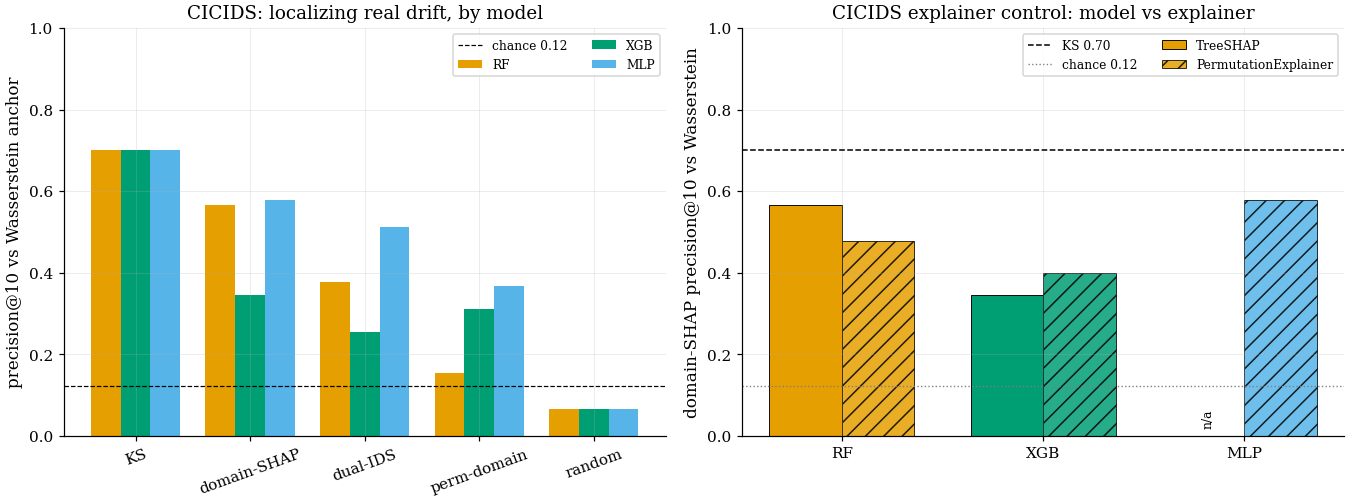

In [10]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.8))

# Panel A: KS vs domain-SHAP vs dual, by model (native explainers)
order = ['ks', 'domain_shap', 'dual_ids', 'perm_domain', 'random']
labels = ['KS', 'domain-SHAP', 'dual-IDS', 'perm-domain', 'random']
xx = np.arange(len(order)); w = 0.26
for bi, model in enumerate(MODELS):
    vals = [cell(mm, 'wasserstein', model) for mm in order]
    axA.bar(xx + (bi - 1) * w, vals, width=w, color=MODEL_COLOR[model], label=model.upper())
axA.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'chance {CHANCE:.2f}')
axA.set_xticks(xx); axA.set_xticklabels(labels, rotation=20)
axA.set_ylabel(f'precision@{K_PRIMARY} vs Wasserstein anchor')
axA.set_ylim(0, 1.0); axA.set_title('CICIDS: localizing real drift, by model')
axA.legend(fontsize=8, ncol=2)

# Panel B: explainer control (TreeSHAP vs Perm), by model
tv = [cdom(mdl, 'treeshap') for mdl in MODELS]; pv = [cdom(mdl, 'perm') for mdl in MODELS]
xb = np.arange(len(MODELS)); wb = 0.36
axB.bar(xb - wb/2, [v if v == v else 0 for v in tv], width=wb, label='TreeSHAP',
        color=[MODEL_COLOR[mdl] for mdl in MODELS], edgecolor='black', linewidth=0.6)
axB.bar(xb + wb/2, pv, width=wb, label='PermutationExplainer', hatch='//',
        color=[MODEL_COLOR[mdl] for mdl in MODELS], edgecolor='black', linewidth=0.6, alpha=0.85)
axB.axhline(KS_MEAN, ls='--', color='black', lw=1.0, label=f'KS {KS_MEAN:.2f}')
axB.axhline(CHANCE, ls=':', color='grey', lw=0.9, label=f'chance {CHANCE:.2f}')
for xi, v in zip(xb - wb/2, tv):
    if v != v:
        axB.text(xi, 0.02, 'n/a', ha='center', va='bottom', fontsize=8, rotation=90)
axB.set_xticks(xb); axB.set_xticklabels([mdl.upper() for mdl in MODELS])
axB.set_ylabel(f'domain-SHAP precision@{K_PRIMARY} vs Wasserstein')
axB.set_ylim(0, 1.0); axB.set_title('CICIDS explainer control: model vs explainer')
axB.legend(fontsize=8, ncol=2)
fig.tight_layout(); save_figure(fig, '14_mlp_cicids_benchmark'); plt.show()

In [11]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'dataset': 'CICIDS2017', 'construction': 'additive leave-one-family-out (as notebook 13)',
    'n_features': N_FEATURES, 'pool_cap': POOL_CAP, 'heldout_families': HELDOUT,
    'models': MODELS, 'seeds': SEEDS, 'k': K_PRIMARY, 'chance': CHANCE, 'margin': MARGIN,
    'replication_by_model': model_summary, 'control_by_model': ctrl_summary,
    'mlp_gate': {'ks': ks_w, 'domain_shap': dom_w, 'dual_ids': dual_w,
                 'ks_minus_dom': ks_minus_dom, 'dual_minus_dom': dual_minus_dom},
    'control_ks_minus_domshap_perm': {'rf': d_rf, 'xgb': d_xgb, 'mlp': d_mlp},
    'replication_verdict': repl, 'control_verdict': control, 'headline': headline,
    'mirrors': 'notebook 13 (D030) + 13b (D031), on CICIDS2017',
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F020',
    title='CICIDS cross-dataset test of the neural drift-localization boundary (with explainer control)',
    context='05_phase3_generalization/14_mlp_cicids_benchmark',
    what_we_did=(
        'Replicated the UNSW neural benchmark (13 / D030) on CICIDS2017, construction held '
        'identical (additive leave-one-family-out, Wasserstein anchor, KS / domain-SHAP / '
        'dual-IDS / perm-domain / random, RF + XGBoost + MLP), with the 13b explainer control '
        'inline (tree domain-SHAP also via PermutationExplainer). SHAP via shap_importance_any. '
        'D032.'
    ),
    what_we_found=(
        'Replication verdict: ' + repl + '; control verdict: ' + control + '. MLP on Wasserstein '
        '(chance %.3f): KS %.3f, domain-SHAP %.3f (KS-dom %+.3f), dual %.3f (dual-dom %+.3f). '
        'Control KS-domainSHAP(Perm): rf %+.3f, xgb %+.3f, mlp %+.3f.'
        % (CHANCE, ks_w, dom_w, ks_minus_dom, dual_w, dual_minus_dom, d_rf, d_xgb, d_mlp)
    ),
    why_it_matters=(
        'Tests whether the notebook-13 neural boundary (a neural domain classifier localizes '
        'drift better than the cheap KS test) is cross-dataset robust or UNSW-specific. Either '
        'outcome sharpens the scope of C2 in the paper. Last planned experiment; next is paper '
        'polish, not more models.'
    ),
)
print('F020 logged.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase3_14_mlp_cicids_benchmark.json
[FINDING LOGGED] F020: CICIDS cross-dataset test of the neural drift-localization boundary (with explainer control)
F020 logged.


## 10. What this settles

Read the replication and control verdicts together against UNSW (13 / 13b):

- **Reproduces + MODEL-DRIVEN** -> the neural boundary is real and cross-dataset:
  a neural domain classifier localizes real drift better than KS on both UNSW and
  CICIDS, and it is the model, not the explainer. The paper states it as a robust,
  scoped boundary of C2.
- **Does not reproduce** -> the UNSW advantage is dataset-specific; on CICIDS KS is
  competitive again. This *strengthens* the headline thesis (explanations do not
  reliably beat the cheap test) and the paper says so.
- **Reproduces but EXPLAINER-DRIVEN on CICIDS** -> dataset-dependent mechanism;
  report the contrast with UNSW honestly.

The core falsification (dual-model SHAP adds nothing) should hold here too, for all
three models -- check the `dual-dom` column stays within margin.

**This is the last experiment.** Next: fold 12 / 13 / 13b / 14 into `paper.tex`
with honest, scoped wording (three-family Fig. 5, the cross-model/cross-dataset
benchmark, the explainer control, the W1-vs-KS caveat), then notation, figures,
tables, and the reproducibility package. No more models.

Record the call by hand:

In [12]:
# add_journal_entry(
#     title='Notebook 14 CICIDS cross-dataset neural benchmark verdict',
#     body='...the CICIDS replication of notebook 13 with the inline explainer control, the '
#          'replication and control verdicts, how they compare to UNSW (13/13b), and what it '
#          'settles for the scope of C2 in the paper. Completes the 11-14 neural generalization.',
# )